# Chip Dynamics — v2 (modular)

Pipeline for chip dynamics analysis. Heavy logic lives in two companion modules:
- `chipanalysis/functions/chip_dynamics.py` — data-loading, rotation, band geometry, analysis loop
- `chipanalysis/functions/detectors.py` — pluggable detector factories

**Swap a detector** by replacing `PILLAR_DETECT_FN` or `OBJECT_DETECT_FN` with any callable
that has the signature `fn(image: np.ndarray, px_um: float) -> bool mask`.

**Cluster use**: call `build_cell_dataframe(...)` directly from a Python script —
no notebook required.


## 1 · Imports & Configuration

In [52]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── chipanalysis pipeline modules ────────────────────────────────────────────
from chipanalysis.functions.chip_dynamics import (
    load_czi,
    get_rotation_fn,
    get_rotated_frame,
    compute_temporal_mean,
    detect_channel_from_mask,
    build_cell_dataframe,
)
from chipanalysis.functions.detectors import (
    make_fluo_detector,
    calibrate_fluo_threshold,
    make_unet_pillar_detector,
    make_unet_detector,          # generic UNet — use for C. elegans, etc.
)

%load_ext autoreload
%autoreload 2
%matplotlib widget


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
# ════════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS — edit this cell before running
# ════════════════════════════════════════════════════════════════════════════

# ── File ─────────────────────────────────────────────────────────────────────
CZI_PATH = "/Users/bisot/Documents/PostDoc2/test_data/ICP/ICP16-03.czi"  # ← change
SCENE    = 5         # scene index (None for files without scenes)

# ── Channels ─────────────────────────────────────────────────────────────────
CHANNEL_BF   = 2      # brightfield channel (used for rotation + pillar detection)
CHANNEL_FLUO = 1      # channel to feed into the object detector
CHANNEL_OBJECT_DETECT = CHANNEL_FLUO
# ── Reference timepoint (pillar / band geometry) ─────────────────────────────
TIMEPOINT_REF = 0     # frame used for rotation alignment and pillar detection

# ── Temporal mean ─────────────────────────────────────────────────────────────
N_FRAMES_MEAN = 10    # number of frames averaged for static background

# ── Timepoints to analyse ────────────────────────────────────────────────────
TIMEPOINTS = list(range(13, 43, 1)) + list(range(60, 80, 1))   # ← adjust to your dataset

TIMEPOINTS = list(range(40, 130, 5))  # ← adjust to your dataset

# ── Pillar detector —  swap make_unet_pillar_detector for any callable ────────
PILLAR_MODEL_PATH = "/Users/bisot/Documents/PostDoc2/training_data_pillars/unet_pillar_newchip.pth"
PILLAR_CROP_COLS  = 500    # edge columns to ignore when projecting pillar mask

# ── Object detector — swap for any callable with (image, px_um) -> bool mask ─
#   Example alternatives (uncomment to use):
#     OBJECT_DETECT_FN = make_unet_detector("path/to/celegans.pth", threshold=0.5)
BG_SIGMA_UM   = 1000.0   # Gaussian σ for spatial BG removal (µm)
MIN_OBJ_UM2   = 25.0     # minimum detected object area (µm²)
MAX_HOLE_UM2  = 5.0      # maximum hole to fill (µm²)
THRESH_FACTOR = 0.2      # fraction of Otsu threshold
# Set FIXED_THRESHOLD to a float to lock the threshold across all frames (ignores THRESH_FACTOR).
# Leave as None to use per-frame Otsu × THRESH_FACTOR (default).
# Auto-calibrate it in section 6 using calibrate_fluo_threshold().
FIXED_THRESHOLD = None   # e.g. 0.05  or  None

# ── Debug flags ───────────────────────────────────────────────────────────────
DEBUG            = True   # show debug visualisations
DEBUG_TIMEPOINT  = 0     # timepoint used for the object-detection debug view


## 2 · Load CZI File & Align (Rotation)

.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value
File        : ICP16-03.czi
Dimensions  : {'S': 8, 'T': 386, 'C': 3, 'M': 4, 'Y': 896, 'X': 896}
Pixel size  : 2.7438 µm/px
  scene 0: 3316×896 px  at (24083, 11742)
  scene 1: 3315×896 px  at (24073, 14245)
  scene 2: 3315×896 px  at (24096, 16757)
  scene 3: 3315×896 px  at (24120, 19283)
  scene 4: 3315×896 px  at (35367, 12483)
  scene 5: 3315×896 px  at (35375, 15029)
  scene 6: 3315×896 px  at (35398, 17513)
  scene 7: 3315×896 px  at (35444, 20064)

Rotation angle applied : -0.50°
Alignment success      : True
  Finding image orientation via FFT...
    → FFT peak: 89.5°  spatial direction: 179.5°
    → Raw rotation: -0.5°  →  applied: -0.5°


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_32065/409545758.py:35: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))


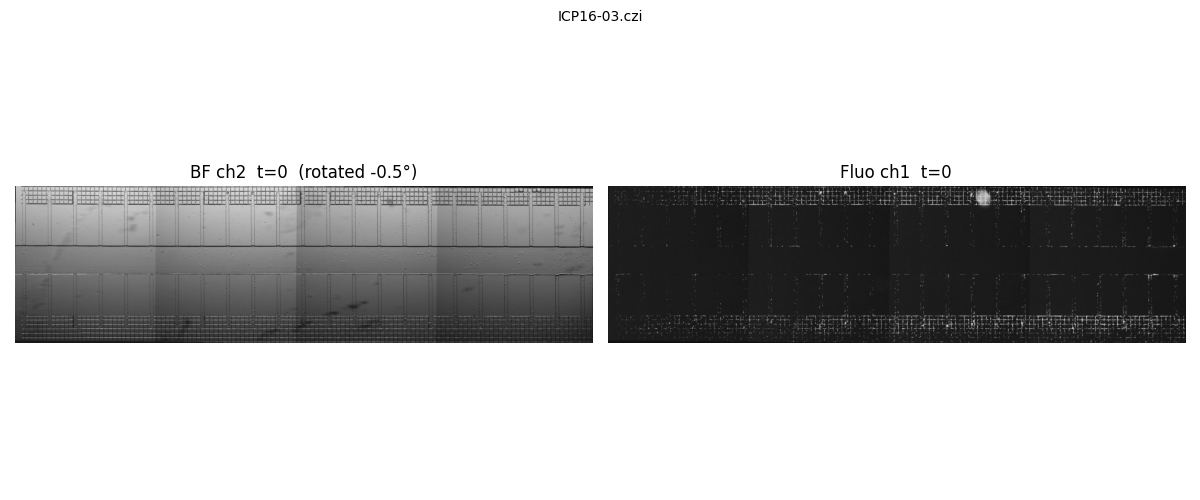

In [54]:
czi, px_um, dim_sizes, pixel_size = load_czi(CZI_PATH)

print(f"File        : {Path(CZI_PATH).name}")
print(f"Dimensions  : {dim_sizes}")
print(f"Pixel size  : {px_um:.4f} µm/px")
if "S" in dim_sizes:
    for s, bb in czi.get_all_scene_bounding_boxes().items():
        print(f"  scene {s}: {bb.w}×{bb.h} px  at ({bb.x}, {bb.y})")

# ── Alignment: find rotation from brightfield at reference timepoint ──────────
# Pass debug=DEBUG to see the FFT orientation figure when DEBUG=True
rotate_fn, align_result = get_rotation_fn(
    czi, bf_channel=CHANNEL_BF, scene=SCENE,
    timepoint=TIMEPOINT_REF, px_um=px_um,
    debug=False,
)
print(f"\nRotation angle applied : {align_result['rotate_angle_deg']:.2f}°")
print(f"Alignment success      : {align_result['success']}")
for msg in align_result["messages"]:
    print(f"  {msg}")


# ── Convenience loader: returns (raw_rotated, disp_rotated) ──────────────────
def load_frame(t, ch, gamma=1.0, stretch_min=1, stretch_max=99.5):
    """Load a frame from the CZI file and return (raw_rotated, disp_rotated)."""
    return get_rotated_frame(czi, t, ch, SCENE, rotate_fn,
                             gamma=gamma,
                             stretch_min=stretch_min,
                             stretch_max=stretch_max)

# ── Preview reference frames ──────────────────────────────────────────────────
img_bf_ref,   img_bf_disp   = load_frame(TIMEPOINT_REF, CHANNEL_BF)
img_fluo_ref, img_fluo_disp = load_frame(TIMEPOINT_REF, CHANNEL_FLUO)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_bf_disp,   cmap="gray"); axes[0].set_title(f"BF ch{CHANNEL_BF}  t={TIMEPOINT_REF}  (rotated {align_result['rotate_angle_deg']:.1f}°)")
axes[1].imshow(img_fluo_disp, cmap="gray"); axes[1].set_title(f"Fluo ch{CHANNEL_FLUO}  t={TIMEPOINT_REF}")
for ax in axes: ax.axis("off")
plt.suptitle(Path(CZI_PATH).name, fontsize=10)
plt.tight_layout(); plt.show()


## 3 · Compute Temporal Mean (Reference Background)

Pixel-wise mean across `N_FRAMES_MEAN` frames — captures static autofluorescence and chip structure.
Subtracting this from each frame isolates what *changes* over time.

> **Cluster tip**: save with `np.save("temporal_mean.npy", temporal_mean)` and load on the cluster
> to skip recomputation.


Temporal mean: 10 frames  ch1  scene=5
  range: [-16.2, 2820.2]


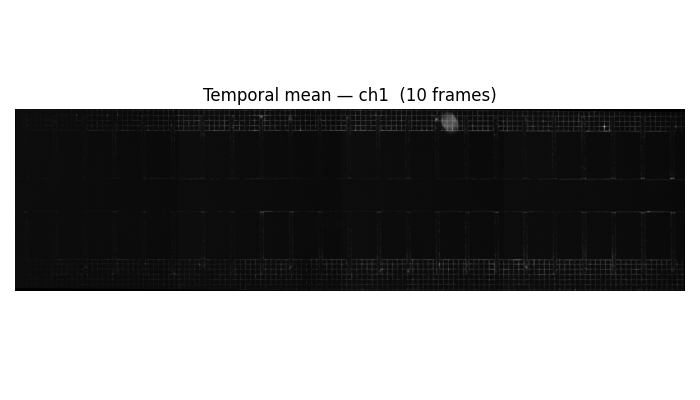

In [55]:
temporal_mean = compute_temporal_mean(
    czi, channel=CHANNEL_FLUO, scene=SCENE,
    rotate_fn=rotate_fn, n_frames=N_FRAMES_MEAN,
)

print(f"Temporal mean: {N_FRAMES_MEAN} frames  ch{CHANNEL_FLUO}  scene={SCENE}")
print(f"  range: [{temporal_mean.min():.1f}, {temporal_mean.max():.1f}]")

# Optional: persist for cluster reuse
# np.save("temporal_mean.npy", temporal_mean)

tm_norm = (temporal_mean - temporal_mean.min()) / (temporal_mean.max() - temporal_mean.min() + 1e-8)
fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(tm_norm, cmap="gray"); ax.axis("off")
ax.set_title(f"Temporal mean — ch{CHANNEL_FLUO}  ({N_FRAMES_MEAN} frames)")
plt.tight_layout(); plt.show()


## 4 · Pillar Detection on Reference Timepoint

`PILLAR_DETECT_FN` is a callable with signature `(image, px_um) → bool mask`.
Swap the factory below to use a different pillar detector without changing anything else.


In [56]:
# ── Build pillar detector (swap factory here to change implementation) ────────
PILLAR_DETECT_FN = make_unet_pillar_detector(
    model_path=PILLAR_MODEL_PATH,
    threshold=0.5,
    patch_size=256,
    patch_stride=128,
    min_pillar_um2=1000.0,
)

# ── Run on reference brightfield frame ────────────────────────────────────────
print(f"Running pillar detector on ch{CHANNEL_BF}  t={TIMEPOINT_REF} …")
pillar_mask = PILLAR_DETECT_FN(img_bf_ref, px_um)
print(f"  Done.  Coverage = {pillar_mask.mean()*100:.2f} %")


Running pillar detector on ch2  t=0 …
  Done.  Coverage = 67.81 %


## 5 · Band Geometry Extraction from Pillar Mask

Row-projection of the binary pillar mask to find the clear gap (microfluidic channel)
between the top and bottom pillar clusters.


In [57]:
band_info = detect_channel_from_mask(pillar_mask, px_um, crop_cols=PILLAR_CROP_COLS)

print(f"Band top     : row {band_info['band_top']}  "
      f"({band_info['band_top']*px_um:.1f} µm)")
print(f"Band bottom  : row {band_info['band_bottom']}  "
      f"({band_info['band_bottom']*px_um:.1f} µm)")
print(f"Band centre  : row {band_info['band_centre_row']:.1f}")
print(f"Band width   : {band_info['band_width_um']:.1f} µm")


Band top     : row 346  (949.4 µm)
Band bottom  : row 499  (1369.2 µm)
Band centre  : row 422.5
Band width   : 419.8 µm


## 6 · Object Detection Function Setup

`OBJECT_DETECT_FN` is a callable `(image, px_um) → bool mask`.
Examples of swappable detectors are shown below — uncomment one.


In [58]:
# ── Option A: fluorescence threshold detector ─────────────────────────────────
# Two threshold modes (controlled by FIXED_THRESHOLD in the Parameters cell):
#
#   FIXED_THRESHOLD = None   → per-frame Otsu × THRESH_FACTOR  (adapts to each frame)
#   FIXED_THRESHOLD = float  → same absolute cutoff for every frame
#
# To auto-calibrate from the reference fluorescence image, uncomment:
FIXED_THRESHOLD = calibrate_fluo_threshold(
    img_fluo_ref, temporal_mean=temporal_mean,
    bg_sigma_um=BG_SIGMA_UM, px_um=px_um,
) * THRESH_FACTOR

OBJECT_DETECT_FN = make_fluo_detector(
    temporal_mean=temporal_mean,
    bg_sigma_um=BG_SIGMA_UM,
    min_obj_um2=MIN_OBJ_UM2,
    max_hole_um2=MAX_HOLE_UM2,
    thresh_factor=THRESH_FACTOR,
    fixed_threshold=FIXED_THRESHOLD,   # None → per-frame Otsu
)

# ── Option B: generic UNet (e.g. C. elegans model) ────────────────────────────
# OBJECT_DETECT_FN = make_unet_detector(
#     model_path="/Users/bisot/Documents/PostDoc2/training_data_worms/unet_celegans_best_newchip.pth",
#     threshold=0.5,
#     min_obj_um2=MIN_OBJ_UM2,   # remove objects smaller than this (µm²); 0 = disabled
# )

print(f"Object detector: {OBJECT_DETECT_FN.__doc__}")
print(f"Will run on channel {CHANNEL_FLUO}")


Object detector: Fluo detector  bg_sigma=1000.0 µm  threshold=fixed=0.0191  min_obj=25.0 µm²
Will run on channel 1


## 7 · Multi-Timepoint Detection Loop → `df_cells`

In [59]:
df_cells = build_cell_dataframe(
    czi=czi,
    scene=SCENE,
    channel=CHANNEL_OBJECT_DETECT,
    timepoints=TIMEPOINTS,
    rotate_fn=rotate_fn,
    detect_fn=OBJECT_DETECT_FN,
    band_info=band_info,
    px_um=px_um,
    min_obj_um2=MIN_OBJ_UM2,
    reference_shape=img_bf_ref.shape,
    verbose=True,
)

print(f"\nTotal objects detected: {len(df_cells)}")
display(df_cells.head(10))


  t=  40  objects detected: 4397
  t=  45  objects detected: 4169
  t=  50  objects detected: 3874
  t=  55  objects detected: 3406
  t=  60  objects detected: 2839
  t=  65  objects detected: 2025
  t=  70  objects detected: 1329
  t=  75  objects detected: 727
  t=  80  objects detected: 413
  t=  85  objects detected: 324
  t=  90  objects detected: 235
  t=  95  objects detected: 205
  t= 100  objects detected: 182
  t= 105  objects detected: 182
  t= 110  objects detected: 172
  t= 115  objects detected: 190
  t= 120  objects detected: 185
  t= 125  objects detected: 185

Total objects detected: 25039


,timepoint,id,centroid_row,centroid_col,dist_to_band_px,dist_to_band_um,area_px,area_um2
0,40,1,2.576923,51.846154,-419.923077,-1152.202334,26.0,195.745310
1,40,2,4.061224,226.714286,-418.438776,-1148.129646,49.0,368.904622
2,40,3,4.500000,251.250000,-418.000000,-1146.925716,64.0,481.834609
3,40,4,2.625000,304.687500,-419.875000,-1152.070418,16.0,120.458652
4,40,5,4.957746,327.478873,-417.542254,-1145.669732,71.0,534.535269
5,40,6,0.875000,430.875000,-421.625000,-1156.872141,8.0,60.229326
6,40,7,8.101449,455.898551,-414.398551,-1137.043910,69.0,519.477938
7,40,8,1.000000,506.285714,-421.500000,-1156.529160,7.0,52.700660
8,40,9,6.337838,554.891892,-416.162162,-1141.882980,74.0,557.121267
9,40,10,1.166667,631.666667,-421.333333,-1156.071854,6.0,45.171995


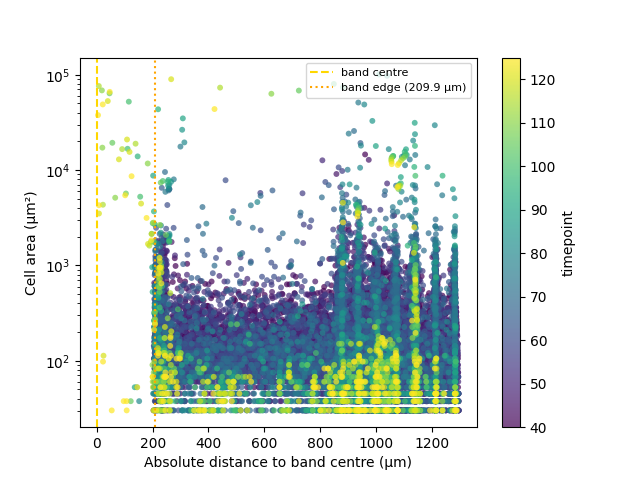

In [67]:
fig, ax = plt.subplots()
select = df_cells[df_cells["timepoint"] <= 120]
select = df_cells

# Left — scatter: distance vs area
sc = ax.scatter(
    np.abs(select["dist_to_band_um"]), select["area_um2"],
    c=select["timepoint"], cmap="viridis",
    s=18, alpha=0.7, linewidths=0,
)
plt.colorbar(sc, ax=ax, label="timepoint")
ax.axvline(0, color="gold", lw=1.5, ls="--", label="band centre")
ax.axvline(band_info['band_half_width_um'], color="orange", lw=1.5, ls=":",
                label=f"band edge ({band_info['band_half_width_um']:.1f} µm)")
ax.set_xlabel("Absolute distance to band centre (µm)")
ax.set_ylabel("Cell area (µm²)")
# ax.set_title(f"Fluo cell size vs position   t={TIMEPOINT_CELLS}", fontsize=10)
ax.legend(fontsize=8)
ax.set_yscale("log")
# ax.set_xscale("log")


In [61]:
wdwegwe

NameError: name 'wdwegwe' is not defined

## 8 · Debug — Pillar Mask & Band Boundaries Overlay

*Gated by `DEBUG = True`*. Validates that the pillar detector and band geometry look correct
on the reference brightfield frame before committing to a full run.


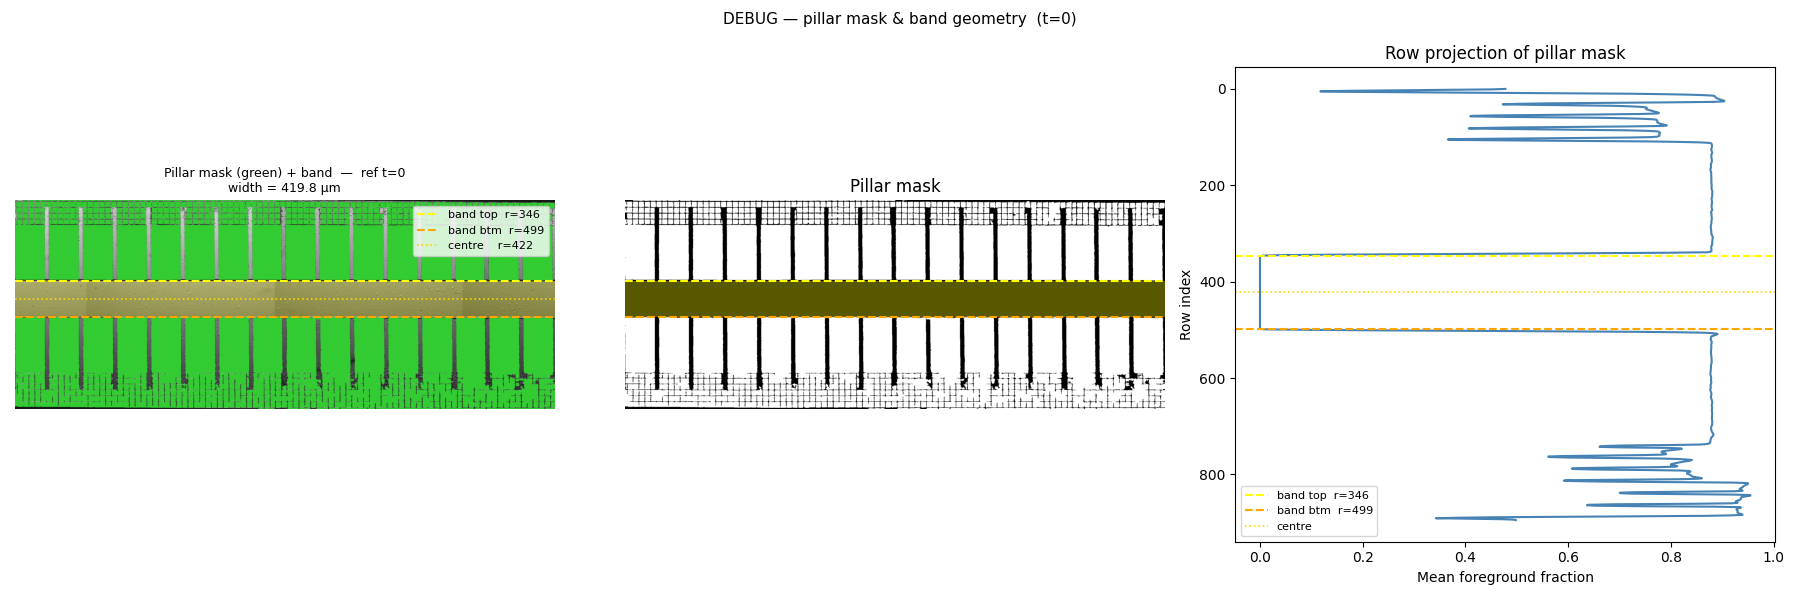

In [ ]:
if DEBUG:
    band_top    = band_info["band_top"]
    band_bottom = band_info["band_bottom"]
    band_centre = band_info["band_centre_row"]
    row_proj    = band_info["row_projection"]
    H, W        = img_bf_ref.shape

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # ── (A) Brightfield + pillar mask overlay ─────────────────────────────────
    bf_norm = (img_bf_disp - img_bf_disp.min()) / (img_bf_disp.max() - img_bf_disp.min() + 1e-8)
    bf_norm = bf_norm[:,PILLAR_CROP_COLS:-PILLAR_CROP_COLS]
    pillar_mask = pillar_mask[:,PILLAR_CROP_COLS:-PILLAR_CROP_COLS]

    overlay = np.stack([bf_norm] * 3, axis=-1).copy()
    overlay[pillar_mask, 0] = 0.2
    overlay[pillar_mask, 1] = 0.8
    overlay[pillar_mask, 2] = 0.2
    axes[0].imshow(np.clip(overlay, 0, 1))
    axes[0].add_patch(plt.Rectangle(
        (0, band_top), W, band_bottom - band_top,
        linewidth=0, facecolor="yellow", alpha=0.25,
    ))
    axes[0].axhline(band_top,    color="yellow", lw=1.5, ls="--", label=f"band top  r={band_top}")
    axes[0].axhline(band_bottom, color="orange", lw=1.5, ls="--", label=f"band btm  r={band_bottom}")
    axes[0].axhline(band_centre, color="gold",   lw=1.2, ls=":",  label=f"centre    r={band_centre:.0f}")
    axes[0].legend(fontsize=8, loc="upper right")
    axes[0].set_title(
        f"Pillar mask (green) + band  —  ref t={TIMEPOINT_REF}\n"
        f"width = {band_info['band_width_um']:.1f} µm", fontsize=9,
    )
    axes[0].axis("off")

    # ── (B) Pillar mask alone ──────────────────────────────────────────────────
    axes[1].imshow(pillar_mask, cmap="gray")
    axes[1].add_patch(plt.Rectangle(
        (0, band_top), W, band_bottom - band_top,
        linewidth=0, facecolor="yellow", alpha=0.35,
    ))
    axes[1].axhline(band_top,    color="yellow", lw=1.5, ls="--")
    axes[1].axhline(band_bottom, color="orange", lw=1.5, ls="--")
    axes[1].set_title("Pillar mask"); axes[1].axis("off")

    # ── (C) Row projection ────────────────────────────────────────────────────
    axes[2].plot(row_proj, np.arange(len(row_proj)), color="steelblue", lw=1.5)
    axes[2].axhline(band_top,    color="yellow", lw=1.5, ls="--", label=f"band top  r={band_top}")
    axes[2].axhline(band_bottom, color="orange", lw=1.5, ls="--", label=f"band btm  r={band_bottom}")
    axes[2].axhline(band_centre, color="gold",   lw=1.2, ls=":",  label="centre")
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Mean foreground fraction")
    axes[2].set_ylabel("Row index")
    axes[2].set_title("Row projection of pillar mask")
    axes[2].legend(fontsize=8)

    plt.suptitle(f"DEBUG — pillar mask & band geometry  (t={TIMEPOINT_REF})", fontsize=11)
    plt.tight_layout(); plt.show()


## 9 · Debug — Object Detection Overlay for Chosen Timepoint

*Gated by `DEBUG = True`*. Set `DEBUG_TIMEPOINT` in the parameters cell.
Shows the detection pipeline intermediate steps for that single frame.


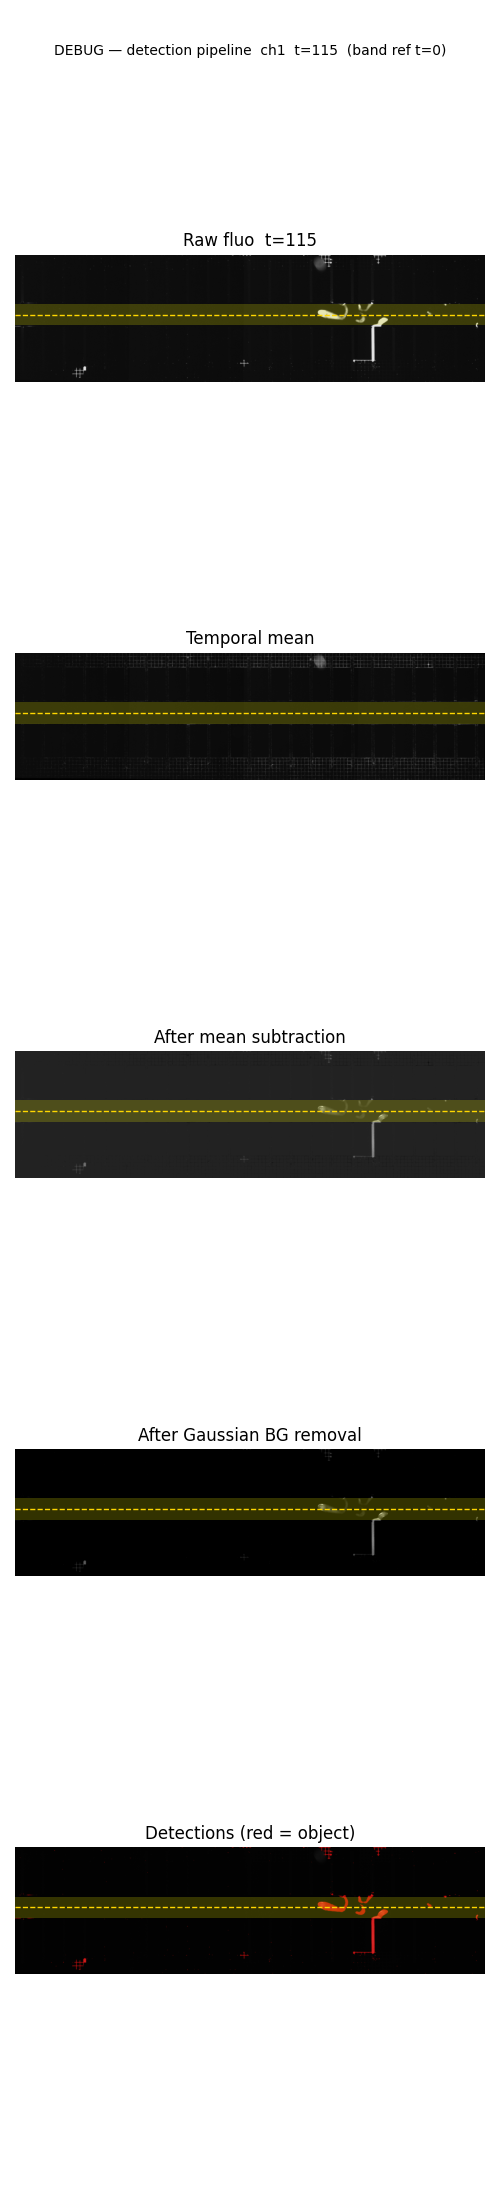

Objects detected at t=115: True


In [ ]:
DEBUG_TIMEPOINT = 115
if DEBUG:
    from skimage import exposure as _exp

    img_dbg_raw,  img_dbg_disp = load_frame(DEBUG_TIMEPOINT, CHANNEL_OBJECT_DETECT)
    img_bf_dbg,   _            = load_frame(DEBUG_TIMEPOINT, CHANNEL_BF)
    binary_dbg = OBJECT_DETECT_FN(img_dbg_raw, px_um)

    # re-build intermediate steps for the display (same logic as make_fluo_detector)
    img_sub  = img_dbg_raw - temporal_mean
    img_sub  = _exp.rescale_intensity(img_sub.astype("float32"), out_range=(0., 1.))
    from skimage.filters import gaussian as _gauss
    bg       = _gauss(img_sub, sigma=BG_SIGMA_UM / px_um, preserve_range=True)
    bg_rem   = _exp.rescale_intensity(np.clip(img_sub - bg, 0, None), out_range=(0., 1.))
    img_norm = _exp.rescale_intensity(img_dbg_raw.astype("float32"), out_range=(0., 1.))

    # final overlay
    ov = np.stack([img_norm] * 3, axis=-1).copy()
    ov[binary_dbg, 0] = ov[binary_dbg, 0] * 0.3 + 0.7
    ov[binary_dbg, 1] = ov[binary_dbg, 1] * 0.3
    ov[binary_dbg, 2] = ov[binary_dbg, 2] * 0.3
    fig, axes = plt.subplots(5, 1, figsize=(5, 22))
    axes[0].imshow(img_dbg_disp, cmap="gray");         axes[0].set_title(f"Raw fluo  t={DEBUG_TIMEPOINT}")
    axes[1].imshow(tm_norm,       cmap="gray");         axes[1].set_title("Temporal mean")
    axes[2].imshow(img_sub,       cmap="gray");         axes[2].set_title("After mean subtraction")
    axes[3].imshow(bg_rem,        cmap="gray");         axes[3].set_title("After Gaussian BG removal")
    axes[4].imshow(np.clip(ov, 0, 1));                  axes[4].set_title("Detections (red = object)")

    band_top    = band_info["band_top"]
    band_bottom = band_info["band_bottom"]
    band_centre = band_info["band_centre_row"]
    W           = img_dbg_raw.shape[1]
    for ax in axes:
        ax.add_patch(plt.Rectangle(
            (0, band_top), W, band_bottom - band_top,
            linewidth=0, facecolor="yellow", alpha=0.2,
        ))
        ax.axhline(band_centre, color="gold", lw=1, ls="--")
        ax.axis("off")

    plt.suptitle(
        f"DEBUG — detection pipeline  ch{CHANNEL_FLUO}  t={DEBUG_TIMEPOINT}  "
        f"(band ref t={TIMEPOINT_REF})",
        fontsize=10,
    )
    plt.tight_layout(); plt.show()
    print(f"Objects detected at t={DEBUG_TIMEPOINT}: {binary_dbg.sum() > 0}")


## 10 · Interactive Selection & Spatial Plot on Brightfield

Filter `df_cells` by any criteria, then pick a random timepoint from the filtered set
and plot detected centroids on the brightfield image for that frame.


In [72]:
# ── Selection criteria — edit to taste ───────────────────────────────────────
SEL_AREA_MIN_UM2  = 25.0      # minimum object area
SEL_AREA_MAX_UM2  = 200    # maximum object area  (None = no upper limit)
SEL_DIST_MAX_UM   = 190     # max |distance to band| in µm  (None = all)
SEL_TIMEPOINTS    = list(range(0, 119))    # list of timepoints to restrict to  (None = all)

# ── Apply filter ──────────────────────────────────────────────────────────────
mask = df_cells["area_um2"] >= SEL_AREA_MIN_UM2
if SEL_AREA_MAX_UM2 is not None:
    mask &= df_cells["area_um2"] <= SEL_AREA_MAX_UM2
if SEL_DIST_MAX_UM is not None:
    mask &= df_cells["dist_to_band_um"].abs() <= SEL_DIST_MAX_UM
if SEL_TIMEPOINTS is not None:
    mask &= df_cells["timepoint"].isin(SEL_TIMEPOINTS)

df_sel = df_cells[mask].copy()
print(f"Selected {len(df_sel)} objects across "
      f"{df_sel['timepoint'].nunique()} timepoints")
display(df_sel.head(10))


Selected 4 objects across 4 timepoints


,timepoint,id,centroid_row,centroid_col,dist_to_band_px,dist_to_band_um,area_px,area_um2
22896,80,131,367.200000,305.000000,-55.300000,-151.734431,5.0,37.643329
23295,85,117,370.142857,307.714286,-52.357143,-143.659697,7.0,52.700660
23594,90,92,373.000000,309.285714,-49.500000,-135.820151,7.0,52.700660
24204,105,80,378.200000,316.400000,-44.300000,-121.552175,5.0,37.643329


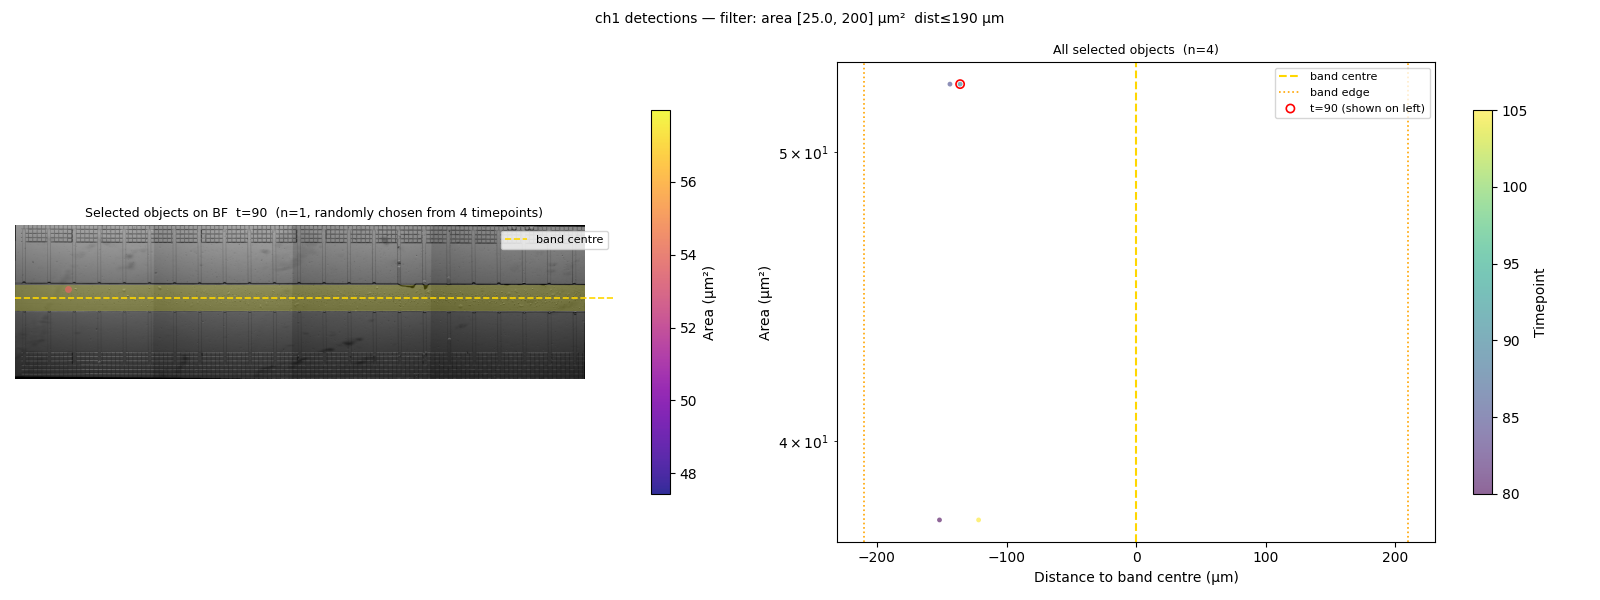

In [76]:
import random

available_timepoints = df_sel["timepoint"].unique().tolist()
if len(available_timepoints) == 0:
    print("No objects match the selection — adjust filter criteria.")
else:
    t_plot = random.choice(available_timepoints)
    df_plot = df_sel[df_sel["timepoint"] == t_plot]
    img_bf_plot, _ = load_frame(t_plot, CHANNEL_BF)

    band_top    = band_info["band_top"]
    band_bottom = band_info["band_bottom"]
    band_centre = band_info["band_centre_row"]
    W           = img_bf_plot.shape[1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── (A) Spatial map on brightfield ────────────────────────────────────────
    axes[0].imshow(img_bf_plot, cmap="gray")
    sc = axes[0].scatter(
        df_plot["centroid_col"], df_plot["centroid_row"],
        c=df_plot["area_um2"], cmap="plasma",
        s=25, alpha=0.85, linewidths=0,
    )
    plt.colorbar(sc, ax=axes[0], label="Area (µm²)", shrink=0.8)
    axes[0].add_patch(plt.Rectangle(
        (0, band_top), W, band_bottom - band_top,
        linewidth=0, facecolor="yellow", alpha=0.2,
    ))
    axes[0].axhline(band_centre, color="gold", lw=1.2, ls="--", label="band centre")
    axes[0].legend(fontsize=8)
    axes[0].set_title(
        f"Selected objects on BF  t={t_plot}  "
        f"(n={len(df_plot)}, randomly chosen from {len(available_timepoints)} timepoints)",
        fontsize=9,
    )
    axes[0].axis("off")

    # ── (B) Distance-to-band vs area scatter (full selection) ─────────────────
    sc2 = axes[1].scatter(
        df_sel["dist_to_band_um"], df_sel["area_um2"],
        c=df_sel["timepoint"], cmap="viridis",
        s=12, alpha=0.6, linewidths=0,
    )
    plt.colorbar(sc2, ax=axes[1], label="Timepoint", shrink=0.8)
    axes[1].axvline(0,                              color="gold",   lw=1.5, ls="--", label="band centre")
    axes[1].axvline( band_info["band_half_width_um"], color="orange", lw=1.2, ls=":",  label="band edge")
    axes[1].axvline(-band_info["band_half_width_um"], color="orange", lw=1.2, ls=":")
    # Highlight the plotted timepoint
    axes[1].scatter(
        df_plot["dist_to_band_um"], df_plot["area_um2"],
        s=35, facecolors="none", edgecolors="red", linewidths=1.2,
        label=f"t={t_plot} (shown on left)",
    )
    axes[1].set_xlabel("Distance to band centre (µm)")
    axes[1].set_ylabel("Area (µm²)")
    axes[1].set_yscale("log")
    axes[1].set_title(f"All selected objects  (n={len(df_sel)})", fontsize=9)
    axes[1].legend(fontsize=8)

    plt.suptitle(
        f"ch{CHANNEL_FLUO} detections — filter: area [{SEL_AREA_MIN_UM2}, {SEL_AREA_MAX_UM2}] µm²  "
        f"dist≤{SEL_DIST_MAX_UM} µm",
        fontsize=10,
    )
    plt.tight_layout(); plt.show()
